<a href="https://colab.research.google.com/github/Sornambiga-S/Netflix-Content-Strategy-Analyzer/blob/Sornambiga-S-patch-1-1/Milestone2_Netflix_Content_Stratergy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Setup & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("cleaned_netflix_titles.csv")

# Quick look
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Analyze Netflix Content Growth Over Time

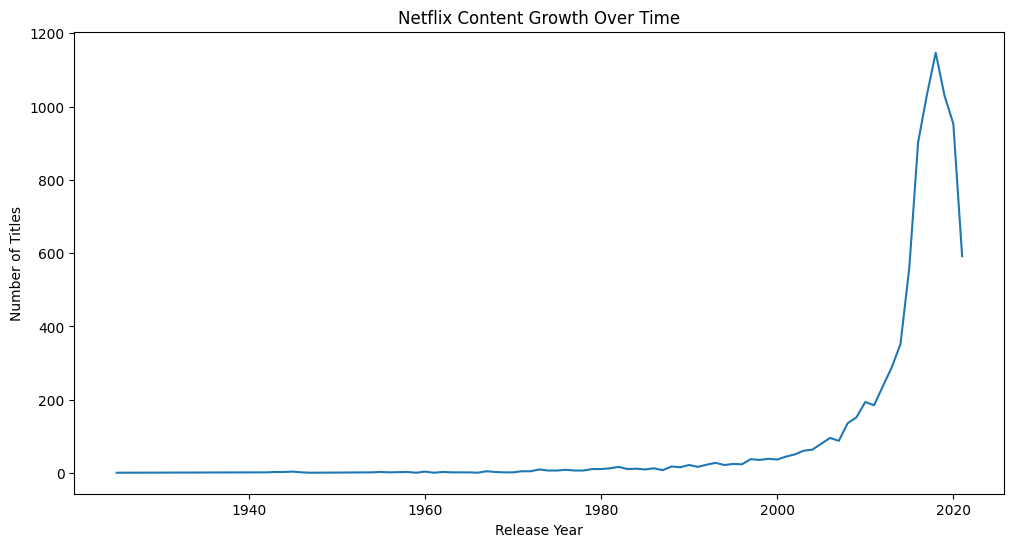

In [4]:
# Convert 'release_year' or 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Content growth by year
content_growth = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=content_growth.index, y=content_growth.values)
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

Distribution of Genres, Ratings, and Content Type

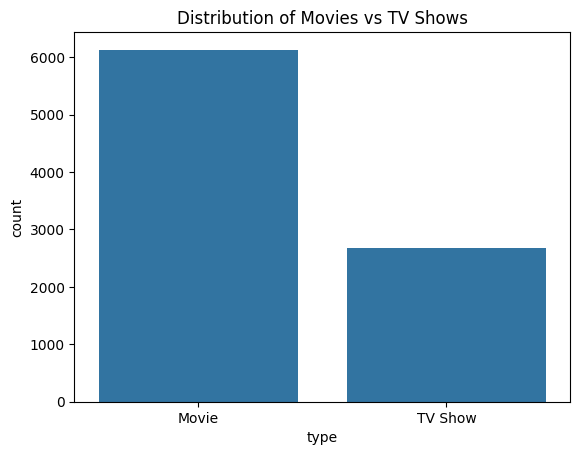

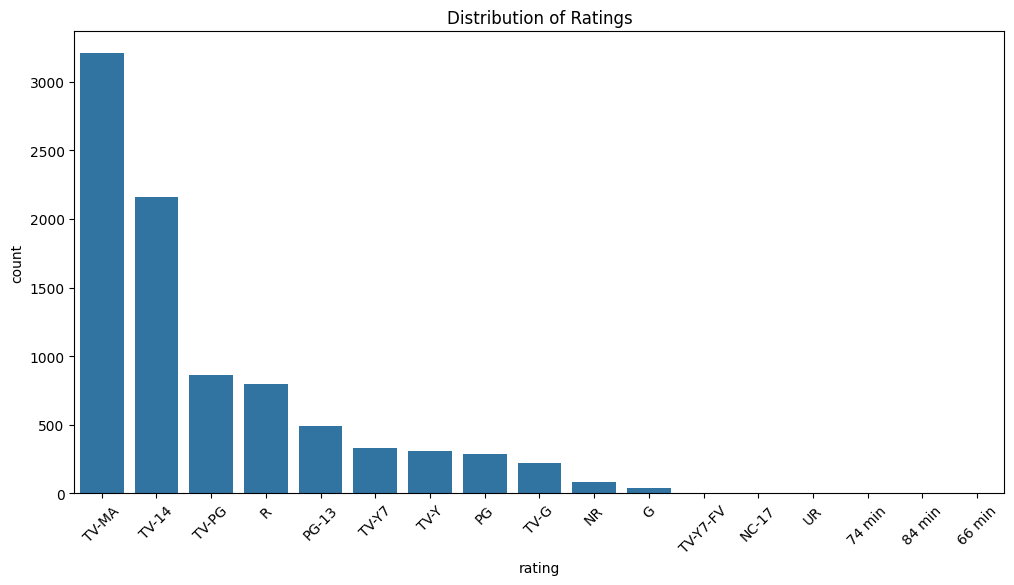

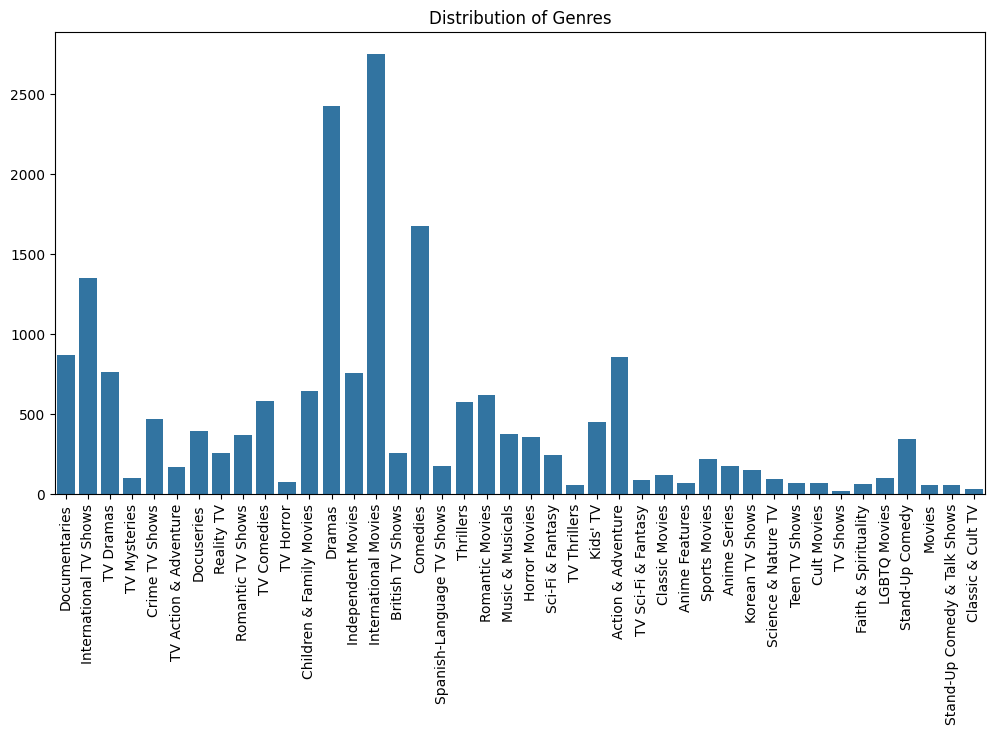

In [5]:
# Content type distribution
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows")
plt.show()

# Ratings distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.title("Distribution of Ratings")
plt.xticks(rotation=45)
plt.show()

# Genre distribution (from 'listed_in' column)
from collections import Counter

genre_list = df['listed_in'].dropna().apply(lambda x: x.split(', '))
all_genres = [g for sublist in genre_list for g in sublist]
genre_counts = Counter(all_genres)

plt.figure(figsize=(12,6))
sns.barplot(x=list(genre_counts.keys()), y=list(genre_counts.values()))
plt.title("Distribution of Genres")
plt.xticks(rotation=90)
plt.show()

Country-Level Content Contributions

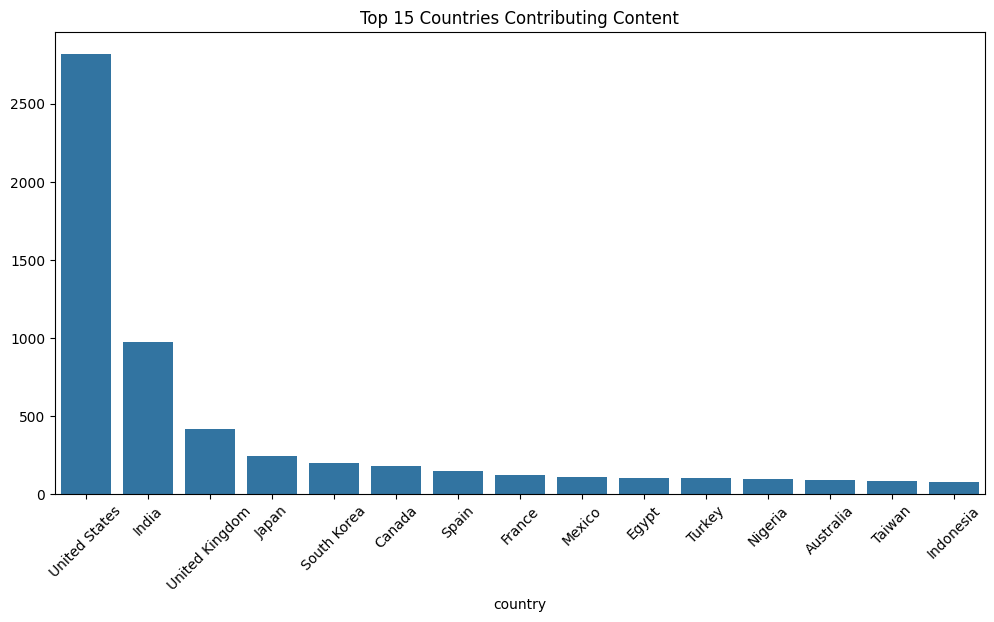

In [6]:
# Count titles by country
country_counts = df['country'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title("Top 15 Countries Contributing Content")
plt.xticks(rotation=45)
plt.show()

Derived Features
a) Content Length Category

In [7]:
# For movies, derive length category
df['duration'] = df['duration'].str.replace(' min','').str.replace(' Season','').str.replace(' Seasons','')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

def length_category(x):
    if pd.isna(x):
        return "Unknown"
    elif x < 60:
        return "Short"
    elif x < 120:
        return "Medium"
    else:
        return "Long"

df['Content_Length_Category'] = df['duration'].apply(length_category)

b) Original vs Licensed

In [8]:
# Simple heuristic: if 'Netflix' appears in 'title' or 'description'
df['Original_vs_Licensed'] = df['title'].apply(lambda x: "Original" if "Netflix" in str(x) else "Licensed")

Engineered Dataset

In [9]:
df.to_csv("netflix_milestone2.csv", index=False)